# Principal Component Analysis (PCA)

## Importing the libraries

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd

## Importing the dataset

In [39]:
dataset = pd.read_csv('Wine.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Applying PCA

In [42]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

## Training the Logistic Regression model on the Training set

In [43]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Making the Confusion Matrix

In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[14  0  0]
 [ 1 15  0]
 [ 0  0  6]]


0.9722222222222222

## Visualising the Training set results

/tmp/ipykernel_29824/3262881861.py:45: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/kygiet/anaconda3/envs/MLapps/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


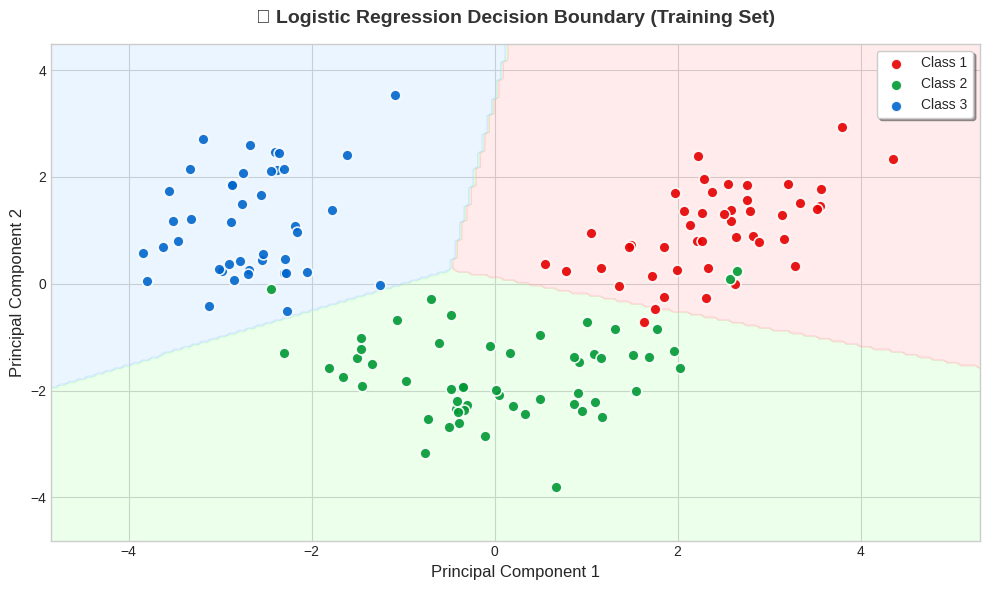

In [45]:


# === Modern visual style ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# === Data ===
X_set, y_set = X_train, y_train

# === Create mesh grid for decision regions ===
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.05),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.05)
)

# === Predict classes for each region ===
Z = classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)

# === Soft pastel shades for better readability ===
bg_colors = ListedColormap(['#ffb3b3', '#b3ffb3', '#b3d9ff'])     # background
point_colors = ListedColormap(['#e60000', '#009933', '#0066cc'])  # data points

# === Decision boundary ===
plt.contourf(X1, X2, Z, alpha=0.25, cmap=bg_colors)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# === Plot training points ===
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=[point_colors(i)],
        label=f'Class {j}',
        s=60,               # larger, clearer points
        edgecolor='white',
        linewidth=1.2,
        alpha=0.9
    )

# === Titles and labels ===
plt.title('🔹 Logistic Regression Decision Boundary (Training Set)',
          fontsize=14, weight='bold', color='#333333', pad=15)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(frameon=True, shadow=True, fontsize=10)
plt.tight_layout()
plt.show()


## Visualising the Test set results

/tmp/ipykernel_29824/3501277777.py:45: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/kygiet/anaconda3/envs/MLapps/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


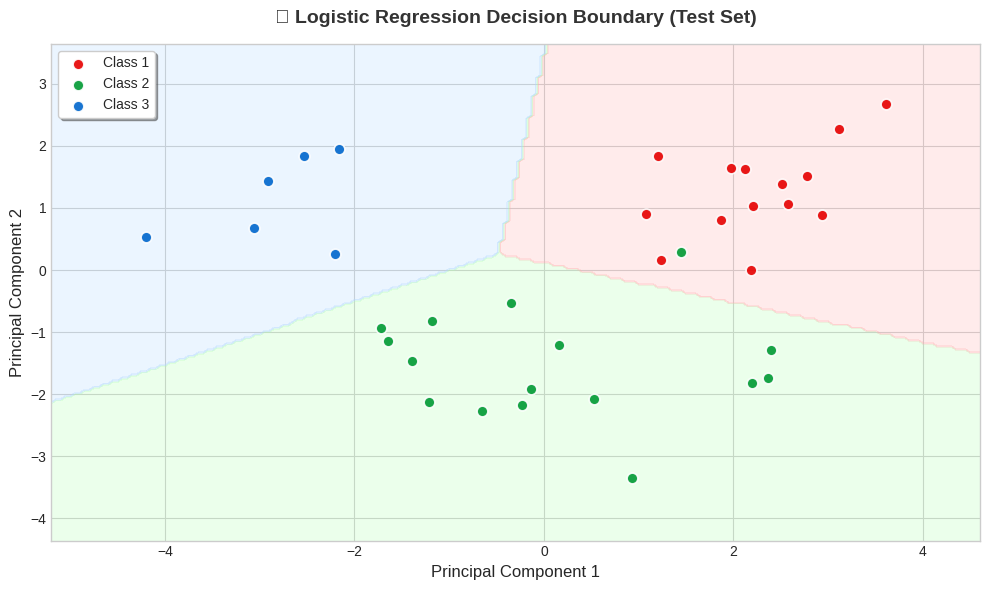

In [46]:


# === Modern visual style ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# === Data ===
X_set, y_set = X_test, y_test

# === Create mesh grid for decision regions ===
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.05),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.05)
)

# === Predict classes for the grid ===
Z = classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)

# === Soft pastel colors ===
bg_colors = ListedColormap(['#ffb3b3', '#b3ffb3', '#b3d9ff'])     # background regions
point_colors = ListedColormap(['#e60000', '#009933', '#0066cc'])  # actual points

# === Decision boundary background ===
plt.contourf(X1, X2, Z, alpha=0.25, cmap=bg_colors)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# === Scatter actual test points ===
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=[point_colors(i)],
        label=f'Class {j}',
        s=60,               # larger points for clarity
        edgecolor='white',  # clean contrast
        linewidth=1.2,
        alpha=0.9
    )

# === Titles and labels ===
plt.title('🔹 Logistic Regression Decision Boundary (Test Set)',
          fontsize=14, weight='bold', color='#333333', pad=15)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(frameon=True, shadow=True, fontsize=10)
plt.tight_layout()
plt.show()
